# HAR simple OLS — recency weighting × window length (3D QLIKE surfaces)

Companion to `HAR_RegressionElasticnet3D.ipynb`. That notebook grid-searched an **elastic
net** `(alpha, l1_ratio)` at every `(window, δ)` cell. This one strips the regularisation out
entirely and fits **plain OLS** instead, so the only two levers left are the rolling **window
length** and the **recency-decay factor δ**.

Each observation in the window is weighted `δ^age` (newest row age 0 → weight 1; oldest →
`δ^(W-1)`), so `δ < 1` tilts the fit toward recent observations and `δ = 1` recovers the
unweighted base case. Weights are normalised to mean 1. The fit is a weighted-least-squares
solve (rows scaled by `√weight`), with a weighted Duan smearing factor for the log→level
back-transform — exactly the OLS baseline of the source notebook, now extended with δ.

**No hyperparameter tuning** here: at every `(window, δ)` we just fit WLS and score the
out-of-sample rolling QLIKE in levels. Because there is no penalty to select, the whole rolling
sweep is **vectorised**: instead of looping over ~2800 OOS days with a fresh `StandardScaler` +
`enet_path` per day, all windowed slices are built once with `sliding_window_view` and solved in
a single batched `np.linalg.solve` (normal equations via `einsum`). This is dramatically faster
than the elastic-net notebook while giving an identical OLS baseline at δ=1.

Every window is scored on the **same common out-of-sample period** so only window length and δ
change. The result is one **3D QLIKE surface per spec** — x = window length, y = δ, z = OLS
QLIKE — answering whether any recency tilt beats the δ=1 (unweighted) OLS edge.

Same three specs as the source notebook (logged HAR + logged exogenous day-t terms, Duan-smearing
log→level back-transform, QLIKE-in-levels scoring):
- **Run 18** — log HAR + log GVZ
- **Run 19** — log HAR + log SPX (RV_ES) + log GVZ
- **Run 20** — log HAR + log crude (RV_crude) + log GVZ

In [54]:
# ===========================================================================
# Cell 1 — Imports & data
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables projection="3d")

# Same aligned daily realized-variance panel used by SimpleHAR_Regressions.ipynb
data = pd.read_parquet("merged_RV_GVZ.parquet")
rv = data["RV_gold"].astype(float)

TRADING_DAYS = 252
WINDOW_YEARS = np.arange(1.0, 7.001, 0.25)          # reduced grid for the 3D sweep
WINDOWS = [int(round(yr * TRADING_DAYS)) for yr in WINDOW_YEARS]
WINDOW_DEFAULT = 504          # 2y, used for the sanity-check cell
EPS = 1e-6                    # QLIKE forecast floor

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"Columns available: {list(data.columns)}")
print(f"Window lengths (days): {WINDOWS}")

RV_gold: 4114 obs, 2010-01-04 .. 2026-05-29
Columns available: ['RV_gold', 'RV_crude', 'RV_ES', 'GVZ_close']
Window lengths (days): [252, 315, 378, 441, 504, 567, 630, 693, 756, 819, 882, 945, 1008, 1071, 1134, 1197, 1260, 1323, 1386, 1449, 1512, 1575, 1638, 1701, 1764]


In [55]:
# ===========================================================================
# Cell 2 — Build the 3 log+GVZ design tables (mirror SimpleHAR Cells 7 & 11)
# ===========================================================================
# Log-HAR components on x = log(RV_gold):
#   x_d[t]=x_t, x_w[t]=mean(x_{t-4..t}), x_m[t]=mean(x_{t-21..t})
#   y_log[t]=x_{t+1}=log(RV_{t+1}); y_level[t]=RV_{t+1} (kept for QLIKE in levels).
# Exogenous day-t terms are logged and known at the close (no look-ahead).

# Strict positivity required for every logged input
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    """Base log-HAR design + optional logged exogenous day-t columns (dict name->series)."""
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)        # log(RV_{t+1})
    df["y_level"] = rv.shift(-1)       # RV_{t+1} in levels, for QLIKE
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])

# Run 18 / 19 / 20 design tables
d_gvz       = build_log_design({"log_GVZ": log_gvz})
d_spx_gvz   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx})
d_crude_gvz = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude})

for name, df in [("d_gvz", d_gvz), ("d_spx_gvz", d_spx_gvz), ("d_crude_gvz", d_crude_gvz)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 18  log+GVZ        cols:", list(d_gvz.columns),       f"({len(d_gvz)} rows)")
print("Run 19  log+SPX+GVZ    cols:", list(d_spx_gvz.columns),   f"({len(d_spx_gvz)} rows)")
print("Run 20  log+crude+GVZ  cols:", list(d_crude_gvz.columns), f"({len(d_crude_gvz)} rows)")
d_gvz.head()

Run 18  log+GVZ        cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'y_log', 'y_level'] (4092 rows)
Run 19  log+SPX+GVZ    cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_ES', 'y_log', 'y_level'] (4092 rows)
Run 20  log+crude+GVZ  cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'y_log', 'y_level'] (4092 rows)


,x_d,x_w,x_m,log_GVZ,y_log,y_level
Date,,,,,,
2010-02-03,2.850663,2.981362,2.933665,3.095125,3.580491,35.891145
2010-02-04,3.580491,3.080406,2.967351,3.302849,3.444815,31.337489
2010-02-05,3.444815,3.158204,2.994161,3.317453,2.911737,18.388714
2010-02-08,2.911737,3.146146,2.996290,3.291383,2.940123,18.918172
2010-02-09,2.940123,3.145566,3.005753,3.236716,3.123939,22.735769


In [56]:
# ===========================================================================
# Cell 3 — Helpers: QLIKE, common-OOS start, recency weights, BATCHED WLS eval
# ===========================================================================
# Common out-of-sample period: every window length is scored on the SAME forecast
# dates (those on/after the longest window has warmed up), so differences reflect
# window length only — mirrors the SimpleHAR_Regressions.ipynb window sweep.
START_DATE = d_gvz.index[max(WINDOWS)]


def _recency_weights(n, delta):
    """Geometric recency weights for a rolling window of length n.

    Newest row (last in the window) gets weight 1; the row `age` steps older gets
    delta**age. delta=1.0 -> equal weights (the unweighted base case). Weights are
    normalised to mean 1 (sum = n) so they only re-balance the fit *relative* to
    each other — keeping the QLIKE comparable across delta.
    """
    if delta >= 1.0:
        return np.ones(n)
    ages = np.arange(n)[::-1]          # oldest = n-1 ... newest = 0
    w = delta ** ages
    return w * (n / w.sum())           # mean-1 normalise

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

# --- Vectorised weighted-OLS log+smearing eval, common-OOS gated ---------------
# Plain OLS = WLS with positional weights from _recency_weights(window, delta):
# minimise sum_i w_i (y_i - X_i beta)^2, solved as ordinary least squares on rows
# scaled by sqrt(w). delta=1.0 -> w=ones recovers ordinary OLS exactly.
#
# OPTIMISATION: with no penalty to tune there is no per-day refit/selection, so the
# entire rolling sweep is done in a few batched numpy ops instead of a Python loop:
#   * sliding_window_view builds every windowed slice X[t-W:t] at once -> (n, W, p)
#   * normal equations A = X'WX, b = X'Wy via einsum -> (n, p, p) and (n, p)
#   * one batched np.linalg.solve(A, b) returns all betas -> (n, p)
#   * forecasts, weighted Duan smearing and residuals are all einsum/broadcast ops
# Returns (mean_qlike, n_oos, n_clipped) — same signature as the source OLS baseline.
def rolling_log_ols_eval(design, feat_cols, window, start_date=None, delta=1.0):
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])  # (N, p)
    yl  = design["y_log"].to_numpy()
    lvl = design["y_level"].to_numpy()
    idx = design.index
    N, p = X.shape

    # Forecast row t uses the window X[t-W:t]; t ranges over [window, N) gated to OOS.
    t_all = np.arange(window, N)
    t_oos = t_all[idx[window:] >= start_date]                      # gate once
    starts = t_oos - window                                        # window start row per t

    # All windowed design / target slices in one strided view: (n_oos, W, p) / (n_oos, W)
    Xwins = np.lib.stride_tricks.sliding_window_view(X, window, axis=0)  # (N-W+1, p, W)
    Xwins = Xwins[starts].transpose(0, 2, 1)                       # (n_oos, W, p)
    ywins = np.lib.stride_tricks.sliding_window_view(yl, window)[starts]  # (n_oos, W)

    w  = _recency_weights(window, delta)                           # (W,) positional weights
    sw = np.sqrt(w)
    Xs = Xwins * sw[None, :, None]                                 # sqrt(w)-scaled rows
    ys = ywins * sw[None, :]

    # Batched normal equations + solve: beta_n = (Xs'Xs)^-1 (Xs'ys)
    A = np.einsum("nwi,nwj->nij", Xs, Xs)                          # (n_oos, p, p)
    b = np.einsum("nwi,nw->ni", Xs, ys)                            # (n_oos, p)
    beta = np.linalg.solve(A, b)                                   # (n_oos, p)

    # Weighted Duan smearing factor from in-window residuals (log space)
    fitted = np.einsum("nwp,np->nw", Xwins, beta)                  # (n_oos, W)
    smear = smear = np.exp(ywins - fitted).mean(axis=1)

    # Forecast for day t in levels: exp(X_t . beta) * smearing
    x_pred = np.einsum("np,np->n", X[t_oos], beta)                 # (n_oos,)
    fc = np.exp(x_pred) * smear
    ac = lvl[t_oos]

    q, clip = _qlike(ac, fc)
    return q.mean(), len(q), clip

print(f"Common OOS start: {START_DATE.date()}  "
      f"({int((d_gvz.index >= START_DATE).sum())} forecast days)")
print(f"Windows={WINDOWS}")

Common OOS start: 2017-02-16  (2328 forecast days)
Windows=[252, 315, 378, 441, 504, 567, 630, 693, 756, 819, 882, 945, 1008, 1071, 1134, 1197, 1260, 1323, 1386, 1449, 1512, 1575, 1638, 1701, 1764]


In [57]:
# ===========================================================================
# Cell 4 — Sanity check at the default 2-year window
# ===========================================================================
specs = [
    ("Run 18  log+GVZ",       d_gvz,       ["x_d", "x_w", "x_m", "log_GVZ"]),
    ("Run 19  log+SPX+GVZ",   d_spx_gvz,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"]),
    ("Run 20  log+crude+GVZ", d_crude_gvz, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"]),
]

print(f"Default window = {WINDOW_DEFAULT} days (~{WINDOW_DEFAULT/TRADING_DAYS:.1f}y), "
      f"common OOS from {START_DATE.date()}\n")
for label, design, feats in specs:
    q_unw, n_unw, _ = rolling_log_ols_eval(design, feats, WINDOW_DEFAULT, delta=1.0)
    q_rec, _, _     = rolling_log_ols_eval(design, feats, WINDOW_DEFAULT, delta=0.99)
    print(f"{label:<24} OLS δ=1.0 {q_unw:.6f} | OLS δ=0.99 {q_rec:.6f}  "
          f"delta {q_rec - q_unw:+.6f}  [n={n_unw}]")

Default window = 504 days (~2.0y), common OOS from 2017-02-16

Run 18  log+GVZ          OLS δ=1.0 0.028434 | OLS δ=0.99 0.028264  delta -0.000170  [n=2328]
Run 19  log+SPX+GVZ      OLS δ=1.0 0.028523 | OLS δ=0.99 0.028419  delta -0.000104  [n=2328]
Run 20  log+crude+GVZ    OLS δ=1.0 0.028371 | OLS δ=0.99 0.028316  delta -0.000055  [n=2328]


In [58]:
# ===========================================================================
# Cell 5 — Window-length sweep (unweighted OLS, delta=1.0), common OOS
# ===========================================================================
ols_by_window = pd.DataFrame(index=WINDOW_YEARS, columns=[s[0] for s in specs], dtype=float)

for label, design, feats in specs:
    for yr, w in zip(WINDOW_YEARS, WINDOWS):
        q_ols, _, _ = rolling_log_ols_eval(design, feats, w, delta=1.0)
        ols_by_window.loc[yr, label] = q_ols
    print(f"{label}: done")

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("\nUnweighted OLS QLIKE by window (years x spec):")
print(ols_by_window.to_string())

print("\nBest window per spec (lower QLIKE = better):")
for label, *_ in specs:
    w_ols = ols_by_window[label].idxmin(); q_ols = ols_by_window.loc[w_ols, label]
    print(f"  {label:<24} OLS best {w_ols:.1f}y={q_ols:.6f}")

Run 18  log+GVZ: done
Run 19  log+SPX+GVZ: done
Run 20  log+crude+GVZ: done

Unweighted OLS QLIKE by window (years x spec):
          Run 18  log+GVZ  Run 19  log+SPX+GVZ  Run 20  log+crude+GVZ
1.000000         0.028222             0.028414               0.028292
1.250000         0.028300             0.028534               0.028393
1.500000         0.028345             0.028473               0.028276
1.750000         0.028348             0.028468               0.028284
2.000000         0.028434             0.028523               0.028371
2.250000         0.028440             0.028524               0.028407
2.500000         0.028545             0.028645               0.028530
2.750000         0.028473             0.028595               0.028524
3.000000         0.028557             0.028636               0.028559
3.250000         0.028496             0.028528               0.028449
3.500000         0.028494             0.028479               0.028443
3.750000         0.028495           

In [59]:
# ===========================================================================
# Cell 6 — Recency-decay (delta) x window sweep: OLS QLIKE cube
# ===========================================================================
# For each spec, sweep the rolling window length AND the recency-decay factor delta.
# At every (window, delta) we fit weighted OLS and score the common-OOS QLIKE — no
# hyperparameter tuning, so each surface cell is simply the OLS QLIKE at that delta.
#   delta = 1.0  -> equal weighting (matches the unweighted ols_by_window column)
#   delta < 1.0  -> geometric down-weighting of older observations
# 5 windows x 5 deltas = 25 fits per spec (75 total) — each a single batched solve.
DELTAS = np.arange(1.0, 0.987, -0.001)  # 1.0 .. 0.95 in -0.01 steps

# OLS QLIKE cube: ols_cube[label] is a DataFrame (index=WINDOW_YEARS, cols=DELTAS)
ols_cube = {label: pd.DataFrame(index=WINDOW_YEARS, columns=DELTAS, dtype=float)
            for label, *_ in specs}

for label, design, feats in specs:
    for yr, w in zip(WINDOW_YEARS, WINDOWS):
        for delta in DELTAS:
            q_ols, _, _ = rolling_log_ols_eval(design, feats, w, delta=delta)
            ols_cube[label].loc[yr, delta] = q_ols
    print(f"{label}: done")

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
for label, *_ in specs:
    print(f"\nOLS QLIKE — {label}  (rows=window yrs, cols=delta):")
    print(ols_cube[label].to_string())
    df = ols_cube[label]
    yr_star = df.min(axis=1).idxmin()
    d_star  = df.loc[yr_star].idxmin()
    q_star  = df.loc[yr_star, d_star]
    q_base  = df.loc[yr_star, 1.0]
    print(f"  min QLIKE {q_star:.6f} at window={yr_star:.1f}y, delta={d_star} "
          f"(vs delta=1.0 at same window {q_base:.6f}, "
          f"{'improves' if q_star < q_base else 'no gain'} {q_star - q_base:+.6f})")

Run 18  log+GVZ: done
Run 19  log+SPX+GVZ: done
Run 20  log+crude+GVZ: done

OLS QLIKE — Run 18  log+GVZ  (rows=window yrs, cols=delta):
          1.000000  0.999000  0.998000  0.997000  0.996000  0.995000  0.994000  0.993000  0.992000  0.991000  0.990000  0.989000  0.988000  0.987000
1.000000  0.028222  0.028203  0.028188  0.028178  0.028173  0.028173  0.028177  0.028187  0.028200  0.028219  0.028242  0.028269  0.028301  0.028338
1.250000  0.028300  0.028246  0.028202  0.028168  0.028144  0.028128  0.028122  0.028124  0.028134  0.028151  0.028175  0.028205  0.028242  0.028284
1.500000  0.028345  0.028269  0.028207  0.028158  0.028123  0.028101  0.028091  0.028093  0.028105  0.028128  0.028159  0.028198  0.028245  0.028299
1.750000  0.028348  0.028262  0.028193  0.028141  0.028105  0.028085  0.028079  0.028088  0.028110  0.028144  0.028189  0.028243  0.028306  0.028377
2.000000  0.028434  0.028320  0.028231  0.028166  0.028124  0.028105  0.028105  0.028123  0.028157  0.028204  0.028264

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_92490/1672009205.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


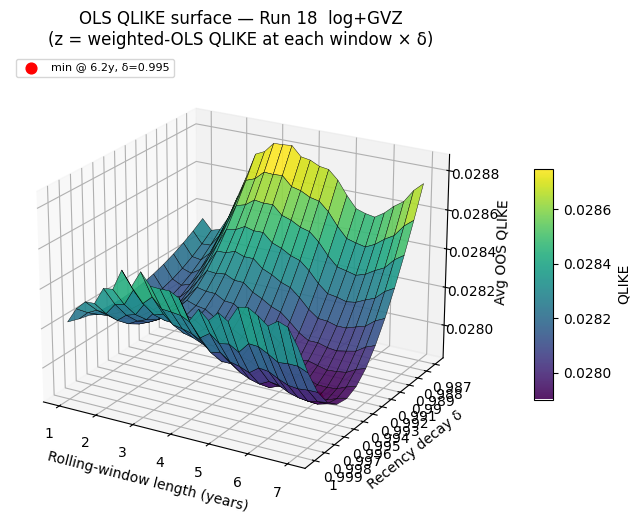

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_92490/1672009205.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


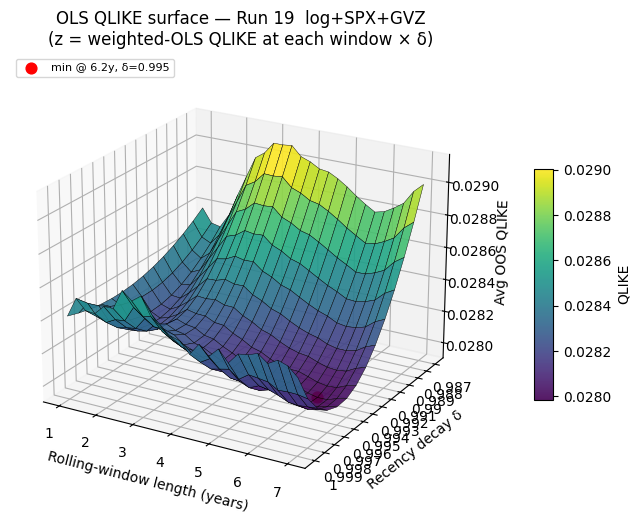

/var/folders/7p/qpcg17xd1kq57541z92kf1jm0000gn/T/ipykernel_92490/1672009205.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


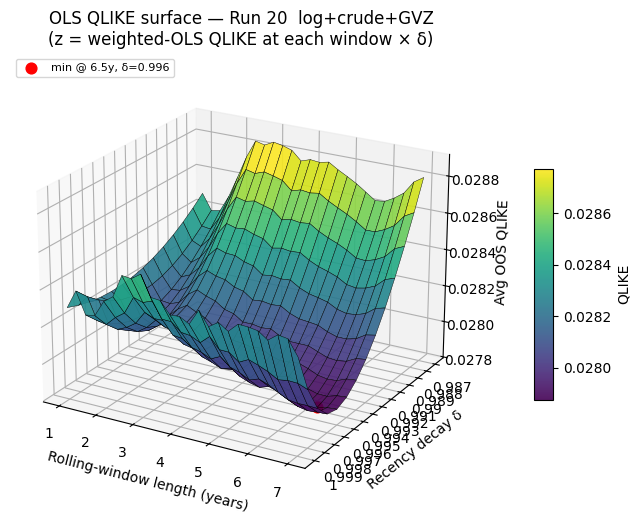

In [60]:
# ===========================================================================
# Cell 7 — 3D QLIKE surfaces: window x delta -> OLS QLIKE (per spec)
# ===========================================================================
# One surface per spec. x = rolling-window length, y = recency-decay delta, and the
# vertical z = average out-of-sample OLS QLIKE (lower = better). delta is plotted on
# an evenly-spaced axis (its values bunch near 1.0) with tick labels showing the
# actual factor. The red marker is the (window, delta) cell with the lowest QLIKE.
ypos = np.arange(len(DELTAS))                         # even spacing for the delta axis
WIN, DELi = np.meshgrid(WINDOW_YEARS, ypos)          # (n_delta, n_window)

def plot_ols_surface(label, df, fname):
    Z = df.to_numpy(dtype=float).T                   # (n_delta, n_window)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection="3d")
    surf = ax.plot_surface(WIN, DELi, Z, cmap="viridis", edgecolor="k",
                           linewidth=0.3, alpha=0.9, antialiased=True)
    # mark the global minimum on the surface
    yr_star = df.min(axis=1).idxmin()
    d_star  = df.loc[yr_star].idxmin()
    q_star  = df.loc[yr_star, d_star]
    ax.scatter([yr_star], [df.columns.get_loc(d_star)], [q_star], color="red", s=60,
           depthshade=False, label=f"min @ {yr_star:.1f}y, δ={d_star}")
    ax.set_xlabel("Rolling-window length (years)")
    ax.set_ylabel("Recency decay δ")
    ax.set_zlabel("Avg OOS QLIKE")
    ax.set_yticks(ypos); ax.set_yticklabels([f"{d:g}" for d in DELTAS])
    ax.set_title(f"OLS QLIKE surface — {label}\n"
                 "(z = weighted-OLS QLIKE at each window × δ)")
    ax.view_init(elev=22, azim=-60)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, pad=0.1, label="QLIKE")
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(fname, dpi=150)
    plt.show()

fnames = {
    "Run 18  log+GVZ":       "qlike_ols_surface_run18.png",
    "Run 19  log+SPX+GVZ":   "qlike_ols_surface_run19.png",
    "Run 20  log+crude+GVZ": "qlike_ols_surface_run20.png",
}
for label, *_ in specs:
    plot_ols_surface(label, ols_cube[label], fnames[label])